In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from colorama import Fore

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_selection import RFECV
import pickle

import warnings
warnings.filterwarnings('ignore')

<h3>Caricamento del dataset</h1>

In [2]:
df=pd.read_csv("apple_quality.csv",sep=',')

<h3>Analisi del dataset</h3>

In [3]:
df

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,good
1,1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,good
2,2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,bad
3,3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,good
4,4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,good
...,...,...,...,...,...,...,...,...,...
3995,3995,0.059386,-1.067408,-3.714549,0.473052,1.697986,2.244055,0.137784,bad
3996,3996,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235,good
3997,3997,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611,bad
3998,3998,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229720,good


**`A_id`**: Identificatore unico per ogni frutto

**`Size`**: Dimensione del frutto

**`Weight`**: Peso del frutto

**`Sweetness`**: Grado di dolcezza del frutto

**`Crunchiness`**: Texture che indica la croccantezza del frutto

**`Juiciness`**: Livello di succosità del frutto

**`Ripeness`**: Stadio di maturazione del frutto

**`Acidity`**: Livello di acidità del frutto

**`Quality`**: Qualità complessiva del frutto

**Descrizione degli attributi del dataset**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   int64  
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4000 non-null   float64
 8   Quality      4000 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 281.4+ KB


In [5]:
df.describe()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1999.500000,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277,0.076877
std,1154.844867,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427,2.110270
min,0.000000,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599,-7.010538
25%,999.750000,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677,-1.377424
50%,1999.500000,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445,0.022609
75%,2999.250000,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212,1.510493
max,3999.000000,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837,7.404736


**Conteggio qualità frutti**

In [6]:
df["Quality"].value_counts()

Quality
good    2004
bad     1996
Name: count, dtype: int64

<h3>Pulizia del dataset</h3>

**Approssimazione dei dati a 2 cifre decimali**

In [7]:
df = df.round(2)
df

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0,-3.97,-2.51,5.35,-1.01,1.84,0.33,-0.49,good
1,1,-1.20,-2.84,3.66,1.59,0.85,0.87,-0.72,good
2,2,-0.29,-1.35,-1.74,-0.34,2.84,-0.04,2.62,bad
3,3,-0.66,-2.27,1.32,-0.10,3.64,-3.41,0.79,good
4,4,1.36,-1.30,-0.38,-0.55,3.03,-1.30,0.50,good
...,...,...,...,...,...,...,...,...,...
3995,3995,0.06,-1.07,-3.71,0.47,1.70,2.24,0.14,bad
3996,3996,-0.29,1.95,-0.20,-0.64,0.02,-1.09,1.85,good
3997,3997,-2.63,-2.14,-2.44,0.66,2.20,4.76,-1.33,bad
3998,3998,-4.01,-1.78,2.37,-0.20,2.16,0.21,-2.23,good


**Rimozione di `A_id`**

In [8]:
df.drop(columns = ["A_id"], inplace=True)
df

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.97,-2.51,5.35,-1.01,1.84,0.33,-0.49,good
1,-1.20,-2.84,3.66,1.59,0.85,0.87,-0.72,good
2,-0.29,-1.35,-1.74,-0.34,2.84,-0.04,2.62,bad
3,-0.66,-2.27,1.32,-0.10,3.64,-3.41,0.79,good
4,1.36,-1.30,-0.38,-0.55,3.03,-1.30,0.50,good
...,...,...,...,...,...,...,...,...
3995,0.06,-1.07,-3.71,0.47,1.70,2.24,0.14,bad
3996,-0.29,1.95,-0.20,-0.64,0.02,-1.09,1.85,good
3997,-2.63,-2.14,-2.44,0.66,2.20,4.76,-1.33,bad
3998,-4.01,-1.78,2.37,-0.20,2.16,0.21,-2.23,good


**Encode in int della qualità**

good => 1
<br>
bad => 0

In [9]:
encoder = LabelEncoder()
df["Quality"] = encoder.fit_transform(df["Quality"])

In [10]:
encoder.classes_

array(['bad', 'good'], dtype=object)

In [11]:
df

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.97,-2.51,5.35,-1.01,1.84,0.33,-0.49,1
1,-1.20,-2.84,3.66,1.59,0.85,0.87,-0.72,1
2,-0.29,-1.35,-1.74,-0.34,2.84,-0.04,2.62,0
3,-0.66,-2.27,1.32,-0.10,3.64,-3.41,0.79,1
4,1.36,-1.30,-0.38,-0.55,3.03,-1.30,0.50,1
...,...,...,...,...,...,...,...,...
3995,0.06,-1.07,-3.71,0.47,1.70,2.24,0.14,0
3996,-0.29,1.95,-0.20,-0.64,0.02,-1.09,1.85,1
3997,-2.63,-2.14,-2.44,0.66,2.20,4.76,-1.33,0
3998,-4.01,-1.78,2.37,-0.20,2.16,0.21,-2.23,1


**Cambio del tipo di `Acidity`**

Per far sì che sia compatibile con tutto il dataset

In [12]:
df = df.astype({'Acidity': 'float64'})

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         4000 non-null   float64
 1   Weight       4000 non-null   float64
 2   Sweetness    4000 non-null   float64
 3   Crunchiness  4000 non-null   float64
 4   Juiciness    4000 non-null   float64
 5   Ripeness     4000 non-null   float64
 6   Acidity      4000 non-null   float64
 7   Quality      4000 non-null   int32  
dtypes: float64(7), int32(1)
memory usage: 234.5 KB


<h3>Preparazione dei dati</h3>

**Separazione di target e feature**

In [14]:
X = df.drop('Quality', axis=1)
y = df["Quality"]

In [15]:
print(X.shape,"\n")
print(type(X),"\n")
print(X.head())

(4000, 7) 

<class 'pandas.core.frame.DataFrame'> 

   Size  Weight  Sweetness  Crunchiness  Juiciness  Ripeness  Acidity
0 -3.97   -2.51       5.35        -1.01       1.84      0.33    -0.49
1 -1.20   -2.84       3.66         1.59       0.85      0.87    -0.72
2 -0.29   -1.35      -1.74        -0.34       2.84     -0.04     2.62
3 -0.66   -2.27       1.32        -0.10       3.64     -3.41     0.79
4  1.36   -1.30      -0.38        -0.55       3.03     -1.30     0.50


**Separazione di data in train e test**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2800, 7)
(2800,)
(1200, 7)
(1200,)


<h3>Creazione del modello</h3>

In [17]:
ppn = Perceptron(max_iter=40, tol=0.001, eta0=0.01, random_state=40)
ppn.fit(X_train, y_train)

Perceptron(eta0=0.01, max_iter=40, random_state=40)

<h3>Verifica del modello</h3>

In [18]:
y_pred = ppn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy, '\n')
print(f'Accuracy: {accuracy*100:.2f}%')

0.6891666666666667 

Accuracy: 68.92%


In [19]:
for xt, yt in zip(X.values, y.values):
    yp = ppn.predict([xt])
    print(f'{Fore.WHITE}{xt} \t', end='')
    if yp == yt:
        pred_color = Fore.GREEN
        act_color = pred_color
    else:
        pred_color = Fore.RED
        act_color = Fore.CYAN
    print(f'{pred_color}{yp}{Fore.WHITE} \t {act_color}{yt}{Fore.WHITE}')

[-3.97 -2.51  5.35 -1.01  1.84  0.33 -0.49] 	[1] 	 1
[-1.2  -2.84  3.66  1.59  0.85  0.87 -0.72] 	[1] 	 1
[-0.29 -1.35 -1.74 -0.34  2.84 -0.04  2.62] 	[1] 	 0
[-0.66 -2.27  1.32 -0.1   3.64 -3.41  0.79] 	[1] 	 1
[ 1.36 -1.3  -0.38 -0.55  3.03 -1.3   0.5 ] 	[1] 	 1
[-3.43 -1.41 -1.91 -0.56 -3.85  1.91 -2.98] 	[0] 	 0
[ 1.33  1.64  0.88 -1.68  3.11 -1.85  2.41] 	[1] 	 1
[-2.   -0.43  1.53 -0.74  0.16  0.97 -1.47] 	[1] 	 1
[-3.87 -3.73  0.99 -1.21  2.29  4.08 -4.87] 	[1] 	 0
[-0.73 -0.44 -4.09  0.6   0.39  1.62  2.19] 	[0] 	 0
[-2.7  -1.33 -1.42 -0.63  2.37  3.4  -2.81] 	[1] 	 0
[ 2.45 -0.56 -1.64  0.94 -2.09  1.21  1.29] 	[0] 	 1
[-0.17 -1.87 -1.77  2.41 -3.09 -0.62 -2.08] 	[0] 	 0
[-1.35 -1.62  2.04  1.75  1.    0.43  1.72] 	[1] 	 1
[ 2.84 -0.34 -1.02  0.89 -1.3   0.58  1.71] 	[1] 	 1
[-2.66 -2.8   4.23  0.7   2.18 -0.09 -1.08] 	[1] 	 1
[-1.47 -1.95 -2.21  0.91  2.86  3.97 -0.56] 	[1] 	 0
[-0.07 -4.71  0.25  2.94  1.41 -2.64  1.25] 	[1] 	 1
[-0.3   1.72 -2.44  3.47  0.45 -0.07  2.49] 	[

Applico la **<span style="color:greenyellow">standardizzazione</span>** in modo da migliorare l'accuratezza dei dati.

In [20]:
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

<h3>Visualizzazione dati standardizzati</h3>

In [21]:
for xt, yt in zip(X.values, y.values):
    yp = ppn.predict([xt])
    print(f'{Fore.WHITE}{xt} \t', end='')
    if yp == yt:
        pred_color = Fore.GREEN
        act_color = pred_color
    else:
        pred_color = Fore.RED
        act_color = Fore.CYAN
    print(f'{pred_color}{yp}{Fore.WHITE} \t {act_color}{yt}{Fore.WHITE}')

[-3.97 -2.51  5.35 -1.01  1.84  0.33 -0.49] 	[1] 	 1
[-1.2  -2.84  3.66  1.59  0.85  0.87 -0.72] 	[1] 	 1
[-0.29 -1.35 -1.74 -0.34  2.84 -0.04  2.62] 	[1] 	 0
[-0.66 -2.27  1.32 -0.1   3.64 -3.41  0.79] 	[1] 	 1
[ 1.36 -1.3  -0.38 -0.55  3.03 -1.3   0.5 ] 	[1] 	 1
[-3.43 -1.41 -1.91 -0.56 -3.85  1.91 -2.98] 	[0] 	 0
[ 1.33  1.64  0.88 -1.68  3.11 -1.85  2.41] 	[1] 	 1
[-2.   -0.43  1.53 -0.74  0.16  0.97 -1.47] 	[1] 	 1
[-3.87 -3.73  0.99 -1.21  2.29  4.08 -4.87] 	[1] 	 0
[-0.73 -0.44 -4.09  0.6   0.39  1.62  2.19] 	[0] 	 0
[-2.7  -1.33 -1.42 -0.63  2.37  3.4  -2.81] 	[1] 	 0
[ 2.45 -0.56 -1.64  0.94 -2.09  1.21  1.29] 	[0] 	 1
[-0.17 -1.87 -1.77  2.41 -3.09 -0.62 -2.08] 	[0] 	 0
[-1.35 -1.62  2.04  1.75  1.    0.43  1.72] 	[1] 	 1
[ 2.84 -0.34 -1.02  0.89 -1.3   0.58  1.71] 	[1] 	 1
[-2.66 -2.8   4.23  0.7   2.18 -0.09 -1.08] 	[1] 	 1
[-1.47 -1.95 -2.21  0.91  2.86  3.97 -0.56] 	[1] 	 0
[-0.07 -4.71  0.25  2.94  1.41 -2.64  1.25] 	[1] 	 1
[-0.3   1.72 -2.44  3.47  0.45 -0.07  2.49] 	[

<h3>Verifica accuratezza con i dati standardizzati</h3>

In [22]:
y_pred = ppn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy, '\n')
print(f'Accuracy: {accuracy*100:.2f}%')

0.6266666666666667 

Accuracy: 62.67%


Come si può vedere l'accuratezza è leggermente aumentata dal 66.92% al 67.83

In [23]:
prediction = ppn.predict(sc.transform([[-3.96, 2.35, -3.68, 1.55, 1.05, 2.55, 1.15]]))
print(f'Prediction: {encoder.inverse_transform(prediction)}')

Prediction: ['bad']


Creo la Confusion Matrix e la visualizzo graficamente grazie a **_<span style="color:yellow">ConfusionMatrixDisplay()</span>_**

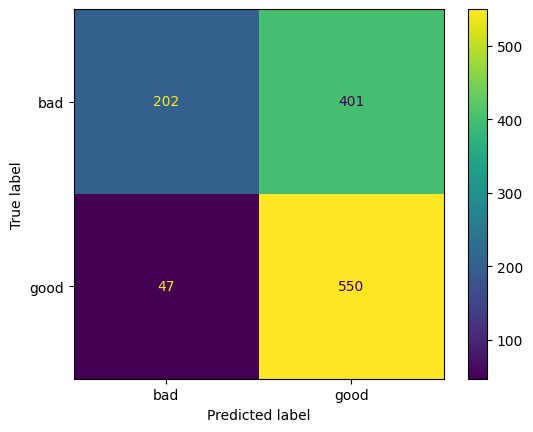

In [24]:
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=encoder.classes_)
cmd.plot()

<h1><span style="color:#FFAA33;font-weight:bold">Logistic Regression</span></h1>

Uso della **_<span style="color:yellow">LogisticRegression()</span>_**

In [25]:
lr = LogisticRegression(random_state=40).fit(X_train, y_train)
y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", "{:.2%}".format(accuracy), '\n')

precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", "{:.2%}".format(precision), '\n')

recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", "{:.2%}".format(recall), '\n')

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1:", "{:.2%}".format(f1), '\n')

Accuracy: 74.92% 

Precision: 74.93% 

Recall: 74.92% 

F1: 74.92% 



In [26]:
for xt, yt in zip(X.values, y.values):
    yp = lr.predict([xt])
    print(f'{Fore.WHITE}{xt} \t', end='')
    if yp == yt:
        pred_color = Fore.GREEN
        act_color = pred_color
    else:
        pred_color = Fore.RED
        act_color = Fore.CYAN
    print(f'{pred_color}{yp}{Fore.WHITE} \t {act_color}{yt}{Fore.WHITE}')

[-3.97 -2.51  5.35 -1.01  1.84  0.33 -0.49] 	[1] 	 1
[-1.2  -2.84  3.66  1.59  0.85  0.87 -0.72] 	[1] 	 1
[-0.29 -1.35 -1.74 -0.34  2.84 -0.04  2.62] 	[0] 	 0
[-0.66 -2.27  1.32 -0.1   3.64 -3.41  0.79] 	[1] 	 1
[ 1.36 -1.3  -0.38 -0.55  3.03 -1.3   0.5 ] 	[1] 	 1
[-3.43 -1.41 -1.91 -0.56 -3.85  1.91 -2.98] 	[0] 	 0
[ 1.33  1.64  0.88 -1.68  3.11 -1.85  2.41] 	[1] 	 1
[-2.   -0.43  1.53 -0.74  0.16  0.97 -1.47] 	[0] 	 1
[-3.87 -3.73  0.99 -1.21  2.29  4.08 -4.87] 	[0] 	 0
[-0.73 -0.44 -4.09  0.6   0.39  1.62  2.19] 	[0] 	 0
[-2.7  -1.33 -1.42 -0.63  2.37  3.4  -2.81] 	[0] 	 0
[ 2.45 -0.56 -1.64  0.94 -2.09  1.21  1.29] 	[0] 	 1
[-0.17 -1.87 -1.77  2.41 -3.09 -0.62 -2.08] 	[0] 	 0
[-1.35 -1.62  2.04  1.75  1.    0.43  1.72] 	[0] 	 1
[ 2.84 -0.34 -1.02  0.89 -1.3   0.58  1.71] 	[1] 	 1
[-2.66 -2.8   4.23  0.7   2.18 -0.09 -1.08] 	[1] 	 1
[-1.47 -1.95 -2.21  0.91  2.86  3.97 -0.56] 	[0] 	 0
[-0.07 -4.71  0.25  2.94  1.41 -2.64  1.25] 	[0] 	 1
[-0.3   1.72 -2.44  3.47  0.45 -0.07  2.49] 	[

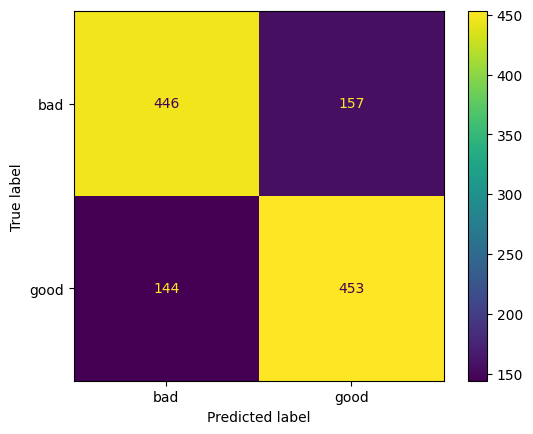

In [27]:
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=encoder.classes_)
cmd.plot()

<h3><span style="font-weight: bold;color:#FFAA33">Cross validation con GridSearchCV su Logistic Regression</span></h1>

In [28]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Best Parameters: {'C': 0.1}
Best Score: 0.7457142857142858


<h1><span style="color:#FFAA33;font-weight:bold">Random forest</span></h1>

Uso il **_<span style="color:yellow;font-weight:bold;font-style:italic">RandomForestClassifier()</span>_**

In [29]:
rfc = RandomForestClassifier(max_depth=2, random_state=40).fit(X_train, y_train)
y_pred = rfc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", "{:.2%}".format(accuracy), '\n')

precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", "{:.2%}".format(precision), '\n')

recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", "{:.2%}".format(recall), '\n')

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1:", "{:.2%}".format(f1), '\n')

Accuracy: 73.33% 

Precision: 74.11% 

Recall: 73.33% 

F1: 73.14% 



In [30]:
for xt, yt in zip(X.values, y.values):
    yp = rfc.predict([xt])
    print(f'{Fore.WHITE}{xt} \t', end='')
    if yp == yt:
        pred_color = Fore.GREEN
        act_color = pred_color
    else:
        pred_color = Fore.RED
        act_color = Fore.CYAN
    print(f'{pred_color}{yp}{Fore.WHITE} \t {act_color}{yt}{Fore.WHITE}')

[-3.97 -2.51  5.35 -1.01  1.84  0.33 -0.49] 	[1] 	 1
[-1.2  -2.84  3.66  1.59  0.85  0.87 -0.72] 	[0] 	 1
[-0.29 -1.35 -1.74 -0.34  2.84 -0.04  2.62] 	[0] 	 0
[-0.66 -2.27  1.32 -0.1   3.64 -3.41  0.79] 	[1] 	 1
[ 1.36 -1.3  -0.38 -0.55  3.03 -1.3   0.5 ] 	[1] 	 1
[-3.43 -1.41 -1.91 -0.56 -3.85  1.91 -2.98] 	[0] 	 0
[ 1.33  1.64  0.88 -1.68  3.11 -1.85  2.41] 	[1] 	 1
[-2.   -0.43  1.53 -0.74  0.16  0.97 -1.47] 	[0] 	 1
[-3.87 -3.73  0.99 -1.21  2.29  4.08 -4.87] 	[0] 	 0
[-0.73 -0.44 -4.09  0.6   0.39  1.62  2.19] 	[0] 	 0
[-2.7  -1.33 -1.42 -0.63  2.37  3.4  -2.81] 	[0] 	 0
[ 2.45 -0.56 -1.64  0.94 -2.09  1.21  1.29] 	[0] 	 1
[-0.17 -1.87 -1.77  2.41 -3.09 -0.62 -2.08] 	[0] 	 0
[-1.35 -1.62  2.04  1.75  1.    0.43  1.72] 	[1] 	 1
[ 2.84 -0.34 -1.02  0.89 -1.3   0.58  1.71] 	[0] 	 1
[-2.66 -2.8   4.23  0.7   2.18 -0.09 -1.08] 	[1] 	 1
[-1.47 -1.95 -2.21  0.91  2.86  3.97 -0.56] 	[0] 	 0
[-0.07 -4.71  0.25  2.94  1.41 -2.64  1.25] 	[1] 	 1
[-0.3   1.72 -2.44  3.47  0.45 -0.07  2.49] 	[

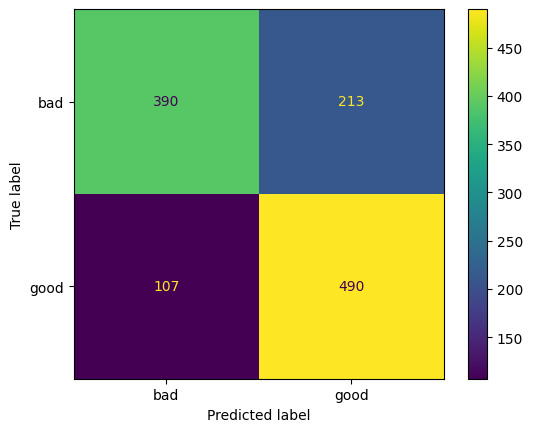

In [31]:
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=encoder.classes_)
cmd.plot()

<h3><span style="font-weight: bold;color:#FFAA33">Cross validation con GridSearchCV su Random Forest</span></h1>

In [ ]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 300, 400, 500],
    'max_depth': [2, 3, 4, 5]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, scoring='accuracy', cv=5)

# Fit the GridSearchCV object to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

<h1><span style="color:#FFAA33;font-weight:bold">Naive Bayes</span></h1>

Uso della **_<span style="color:yellow;font-weight:bold;font-style:italic">GaussianNB()</span>_**

In [ ]:
gnb = GaussianNB().fit(X_train, y_train)
y_pred = gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", "{:.2%}".format(accuracy), '\n')

precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", "{:.2%}".format(precision), '\n')

recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", "{:.2%}".format(recall), '\n')

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1:", "{:.2%}".format(f1), '\n')

Accuracy: 76.17% 

Precision: 76.18% 

Recall: 76.17% 

F1: 76.16% 



In [ ]:
for xt, yt in zip(X.values, y.values):
    yp = gnb.predict([xt])
    print(f'{Fore.WHITE}{xt} \t', end='')
    if yp == yt:
        pred_color = Fore.GREEN
        act_color = pred_color
    else:
        pred_color = Fore.RED
        act_color = Fore.CYAN
    print(f'{pred_color}{yp}{Fore.WHITE} \t {act_color}{yt}{Fore.WHITE}')

[-3.97 -2.51  5.35 -1.01  1.84  0.33 -0.49] 	[1] 	 1
[-1.2  -2.84  3.66  1.59  0.85  0.87 -0.72] 	[1] 	 1
[-0.29 -1.35 -1.74 -0.34  2.84 -0.04  2.62] 	[0] 	 0
[-0.66 -2.27  1.32 -0.1   3.64 -3.41  0.79] 	[1] 	 1
[ 1.36 -1.3  -0.38 -0.55  3.03 -1.3   0.5 ] 	[1] 	 1
[-3.43 -1.41 -1.91 -0.56 -3.85  1.91 -2.98] 	[0] 	 0
[ 1.33  1.64  0.88 -1.68  3.11 -1.85  2.41] 	[1] 	 1
[-2.   -0.43  1.53 -0.74  0.16  0.97 -1.47] 	[0] 	 1
[-3.87 -3.73  0.99 -1.21  2.29  4.08 -4.87] 	[1] 	 0
[-0.73 -0.44 -4.09  0.6   0.39  1.62  2.19] 	[0] 	 0
[-2.7  -1.33 -1.42 -0.63  2.37  3.4  -2.81] 	[0] 	 0
[ 2.45 -0.56 -1.64  0.94 -2.09  1.21  1.29] 	[0] 	 1
[-0.17 -1.87 -1.77  2.41 -3.09 -0.62 -2.08] 	[0] 	 0
[-1.35 -1.62  2.04  1.75  1.    0.43  1.72] 	[1] 	 1
[ 2.84 -0.34 -1.02  0.89 -1.3   0.58  1.71] 	[1] 	 1
[-2.66 -2.8   4.23  0.7   2.18 -0.09 -1.08] 	[1] 	 1
[-1.47 -1.95 -2.21  0.91  2.86  3.97 -0.56] 	[0] 	 0
[-0.07 -4.71  0.25  2.94  1.41 -2.64  1.25] 	[1] 	 1
[-0.3   1.72 -2.44  3.47  0.45 -0.07  2.49] 	[

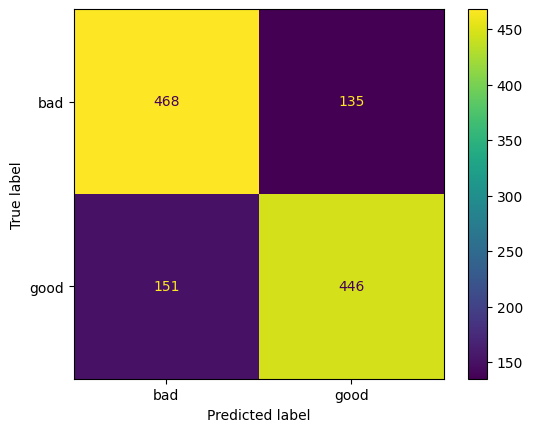

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=encoder.classes_)
cmd.plot()

<h5>Come si può vedere dai risultati, l'algortitmo di machine learning più efficiente e funzionante per questo dataset è il <span style="font-weight:bold;font-style:italic;color:#FFAA33">Naive Bayes.</span></h5>

<h3><span style="font-weight: bold;color:#FFAA33">Cross validation con GridSearchCV su Naive Bayes</span></h1>

In [ ]:
# gridsearchcv with gnb
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
}

grid_search = GridSearchCV(estimator=gnb, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Best Parameters: {'var_smoothing': 0.012328467394420659}
Best Score: 0.7417857142857144


<h1><span style="font-weight: bold">Eliminazione features con recursive feature elimination</span></h1>

<h3>Verifica della correlazione tra features</h3>

<p>Random Forest</p>

Optimal number of features : 7
Ranking of features : [1 1 1 1 1 1 1]
Selected features : [ True  True  True  True  True  True  True]
Grid Scores : [0.59107143 0.66785714 0.70857143 0.72571429 0.72857143 0.73321429
 0.7375    ]
Feature names :       Size  Weight  Sweetness  Crunchiness  Juiciness  Ripeness  Acidity
0    -3.97   -2.51       5.35        -1.01       1.84      0.33    -0.49
1    -1.20   -2.84       3.66         1.59       0.85      0.87    -0.72
2    -0.29   -1.35      -1.74        -0.34       2.84     -0.04     2.62
3    -0.66   -2.27       1.32        -0.10       3.64     -3.41     0.79
4     1.36   -1.30      -0.38        -0.55       3.03     -1.30     0.50
...    ...     ...        ...          ...        ...       ...      ...
3995  0.06   -1.07      -3.71         0.47       1.70      2.24     0.14
3996 -0.29    1.95      -0.20        -0.64       0.02     -1.09     1.85
3997 -2.63   -2.14      -2.44         0.66       2.20      4.76    -1.33
3998 -4.01   -1.78       2.

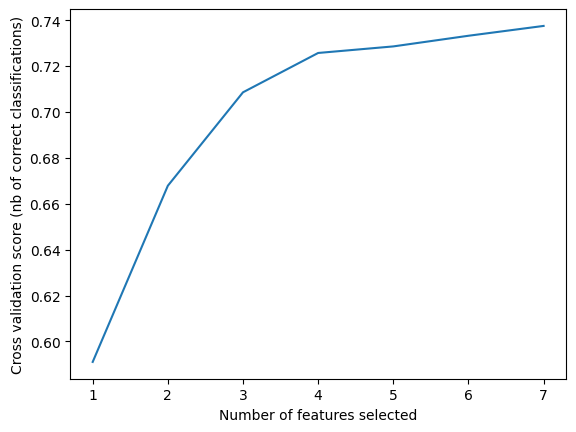

In [ ]:
rfc = RandomForestClassifier(max_depth=2, random_state=40)
rfecv = RFECV(estimator=rfc, step=1, cv=StratifiedKFold(5), scoring='accuracy')
rfecv.fit(X_train, y_train)

print("Optimal number of features : %d" % rfecv.n_features_)
print("Ranking of features : %s" % rfecv.ranking_)
print("Selected features : %s" % rfecv.support_)
print("Grid Scores : %s" % rfecv.cv_results_['mean_test_score'])
print("Feature names : %s" % X)

plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (nb of correct classifications)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.show()

X_train = rfecv.transform(X_train)
X_test = rfecv.transform(X_test)

In [ ]:
rfc = RandomForestClassifier(max_depth=2, random_state=40).fit(X_train, y_train)
y_pred = rfc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", "{:.2%}".format(accuracy), '\n')

precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", "{:.2%}".format(precision), '\n')

recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", "{:.2%}".format(recall), '\n')

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1:", "{:.2%}".format(f1), '\n')

Accuracy: 73.33% 

Precision: 74.11% 

Recall: 73.33% 

F1: 73.14% 



In [ ]:
for xt, yt in zip(X.values, y.values):
    yp = rfc.predict([xt])
    print(f'{Fore.WHITE}{xt} \t', end='')
    if yp == yt:
        pred_color = Fore.GREEN
        act_color = pred_color
    else:
        pred_color = Fore.RED
        act_color = Fore.CYAN
    print(f'{pred_color}{yp}{Fore.WHITE} \t {act_color}{yt}{Fore.WHITE}')

[-3.97 -2.51  5.35 -1.01  1.84  0.33 -0.49] 	[1] 	 1
[-1.2  -2.84  3.66  1.59  0.85  0.87 -0.72] 	[0] 	 1
[-0.29 -1.35 -1.74 -0.34  2.84 -0.04  2.62] 	[0] 	 0
[-0.66 -2.27  1.32 -0.1   3.64 -3.41  0.79] 	[1] 	 1
[ 1.36 -1.3  -0.38 -0.55  3.03 -1.3   0.5 ] 	[1] 	 1
[-3.43 -1.41 -1.91 -0.56 -3.85  1.91 -2.98] 	[0] 	 0
[ 1.33  1.64  0.88 -1.68  3.11 -1.85  2.41] 	[1] 	 1
[-2.   -0.43  1.53 -0.74  0.16  0.97 -1.47] 	[0] 	 1
[-3.87 -3.73  0.99 -1.21  2.29  4.08 -4.87] 	[0] 	 0
[-0.73 -0.44 -4.09  0.6   0.39  1.62  2.19] 	[0] 	 0
[-2.7  -1.33 -1.42 -0.63  2.37  3.4  -2.81] 	[0] 	 0
[ 2.45 -0.56 -1.64  0.94 -2.09  1.21  1.29] 	[0] 	 1
[-0.17 -1.87 -1.77  2.41 -3.09 -0.62 -2.08] 	[0] 	 0
[-1.35 -1.62  2.04  1.75  1.    0.43  1.72] 	[1] 	 1
[ 2.84 -0.34 -1.02  0.89 -1.3   0.58  1.71] 	[0] 	 1
[-2.66 -2.8   4.23  0.7   2.18 -0.09 -1.08] 	[1] 	 1
[-1.47 -1.95 -2.21  0.91  2.86  3.97 -0.56] 	[0] 	 0
[-0.07 -4.71  0.25  2.94  1.41 -2.64  1.25] 	[1] 	 1
[-0.3   1.72 -2.44  3.47  0.45 -0.07  2.49] 	[

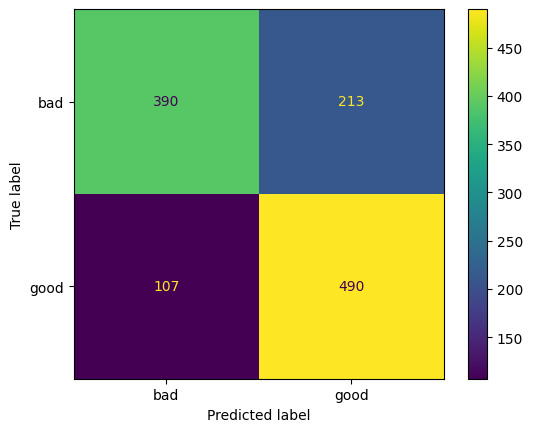

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=encoder.classes_)
cmd.plot()

In [ ]:
param_grid = {
    'n_estimators': [100, 300, 400, 500],
    'max_depth': [2, 3, 4, 5]
}

grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Best Parameters: {'max_depth': 5, 'n_estimators': 400}
Best Score: 0.8375


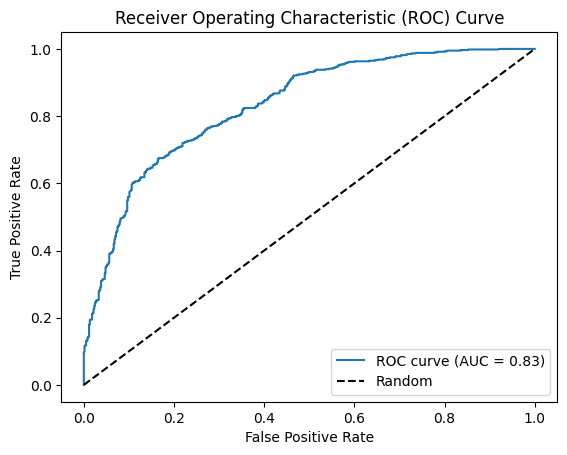

In [ ]:
# Assuming you have the predicted probabilities for the positive class
y_pred_proba = rfc.predict_proba(X_test)[:, 1]

# Compute the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute the area under the ROC curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


<p>Gaussian Naive Bayes</p>

In [ ]:
gnb = GaussianNB().fit(X_train, y_train)
y_pred = gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", "{:.2%}".format(accuracy), '\n')

precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", "{:.2%}".format(precision), '\n')

recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", "{:.2%}".format(recall), '\n')

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1:", "{:.2%}".format(f1), '\n')

Accuracy: 76.17% 

Precision: 76.18% 

Recall: 76.17% 

F1: 76.16% 



In [ ]:
for xt, yt in zip(X.values, y.values):
    yp = gnb.predict([xt])
    print(f'{Fore.WHITE}{xt} \t', end='')
    if yp == yt:
        pred_color = Fore.GREEN
        act_color = pred_color
    else:
        pred_color = Fore.RED
        act_color = Fore.CYAN
    print(f'{pred_color}{yp}{Fore.WHITE} \t {act_color}{yt}{Fore.WHITE}')

[-3.97 -2.51  5.35 -1.01  1.84  0.33 -0.49] 	[1] 	 1
[-1.2  -2.84  3.66  1.59  0.85  0.87 -0.72] 	[1] 	 1
[-0.29 -1.35 -1.74 -0.34  2.84 -0.04  2.62] 	[0] 	 0
[-0.66 -2.27  1.32 -0.1   3.64 -3.41  0.79] 	[1] 	 1
[ 1.36 -1.3  -0.38 -0.55  3.03 -1.3   0.5 ] 	[1] 	 1
[-3.43 -1.41 -1.91 -0.56 -3.85  1.91 -2.98] 	[0] 	 0
[ 1.33  1.64  0.88 -1.68  3.11 -1.85  2.41] 	[1] 	 1
[-2.   -0.43  1.53 -0.74  0.16  0.97 -1.47] 	[0] 	 1
[-3.87 -3.73  0.99 -1.21  2.29  4.08 -4.87] 	[1] 	 0
[-0.73 -0.44 -4.09  0.6   0.39  1.62  2.19] 	[0] 	 0
[-2.7  -1.33 -1.42 -0.63  2.37  3.4  -2.81] 	[0] 	 0
[ 2.45 -0.56 -1.64  0.94 -2.09  1.21  1.29] 	[0] 	 1
[-0.17 -1.87 -1.77  2.41 -3.09 -0.62 -2.08] 	[0] 	 0
[-1.35 -1.62  2.04  1.75  1.    0.43  1.72] 	[1] 	 1
[ 2.84 -0.34 -1.02  0.89 -1.3   0.58  1.71] 	[1] 	 1
[-2.66 -2.8   4.23  0.7   2.18 -0.09 -1.08] 	[1] 	 1
[-1.47 -1.95 -2.21  0.91  2.86  3.97 -0.56] 	[0] 	 0
[-0.07 -4.71  0.25  2.94  1.41 -2.64  1.25] 	[1] 	 1
[-0.3   1.72 -2.44  3.47  0.45 -0.07  2.49] 	[

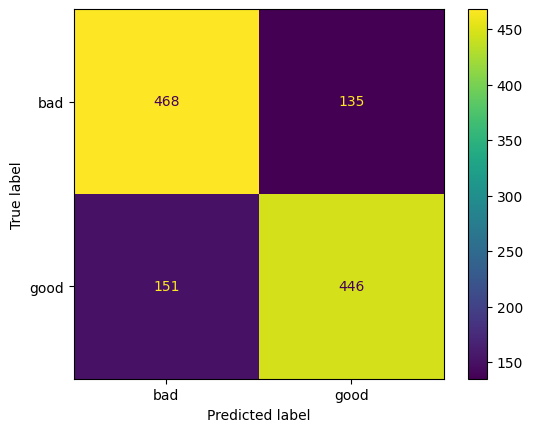

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=encoder.classes_)
cmd.plot()

In [ ]:
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
}

grid_search = GridSearchCV(estimator=gnb, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)

Best Parameters: {'var_smoothing': 0.012328467394420659}
Best Score: 0.7417857142857144


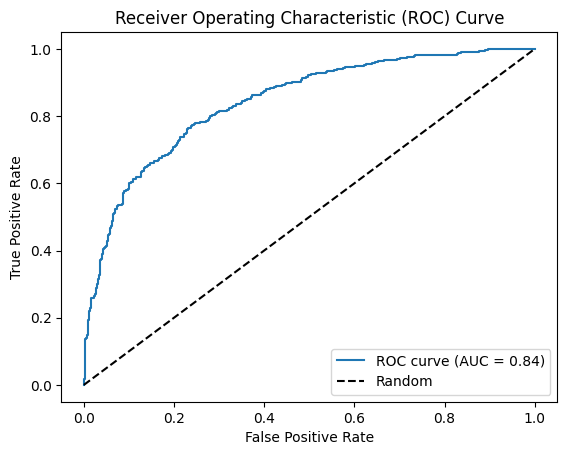

In [ ]:
# Assuming you have the predicted probabilities for the positive class
y_pred_proba = gnb.predict_proba(X_test)[:, 1]

# Compute the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute the area under the ROC curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


<h5>Come si può vedere dal risultato AUC, il modello migliore è il <span style="font-weight:bold;font-style:italic;color:#FFAA33">Gaussian Naive Bayes.</span></h5>

<h2>Salvataggio del modello mediante la libreria <span style="font-weight:bold;font-style:italic;">Pickle.</span>

In [ ]:
filename = "best_model.sav"
pickle.dump(gnb, open(filename, 'wb'))
load_model = pickle.load(open(filename, 'rb'))
print(load_model)
print("Salvataggio riuscito")
load_model.predict(X_test)
print(X_test.shape)

Prob = load_model.predict_proba(X_test)
print("Accuracy: ", load_model.score(X_test, y_test))

GaussianNB()
Salvataggio riuscito
(1200, 7)
Accuracy:  0.7616666666666667
